# Train and save the model

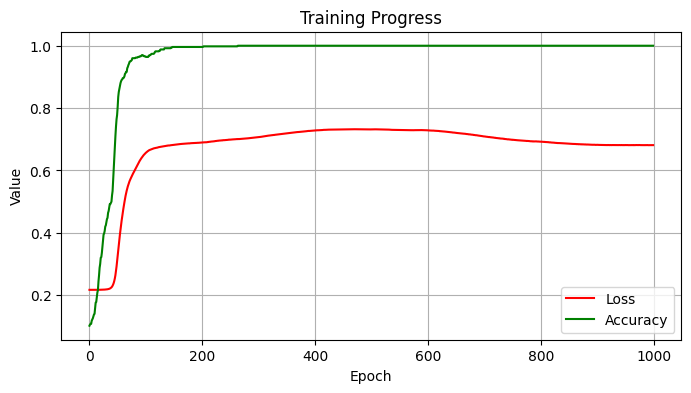

Epoch: 1000 | Loss: 0.6811900 | Corr: 1.0000000 | Lambda 0.0100000
Training time: 1081.19 seconds
Number 0: 0.939
Number 1: 0.942
Number 2: 0.813
Number 3: 0.886
Number 4: 0.632
Number 5: 0.745
Number 6: 0.915
Number 7: 0.664
Number 8: 0.818
Number 9: 0.957
Total: 0.8311


In [15]:
import matplotlib.pyplot as plt
from modules import load_dataset, forward, backward, loss, regularize, test, update, save, load, ctypes
import numpy as np
import time
from IPython.display import clear_output

input_data, input_labels, classes, classes_num, one_hot = load_dataset("data/train", 50)
layers = [256, 128]
layers.insert(0, input_data[0].size)
layers.append(classes_num)

layers_ptr = np.array(layers, dtype=np.int32).ctypes.data_as(ctypes.POINTER(ctypes.c_int))
layers_num = len(layers) - 1

w = []
b = []

np.random.seed(42)
for i in range(layers_num):
    w.append(np.random.randn(layers[i], layers[i+1]) * 0.01)
    b.append(np.zeros(layers[i+1]))

epochs = 1000
epoch_loss = 0
lr = 0.001
ld = 0.00001
fmaps_num = len(input_data)
pe = 0
mpe = 10

loss_history = []
acc_history = []

s = time.time()
print("Arch:", layers)
print("Samples:", fmaps_num)

for i in range(epochs):
    total_loss = 0
    total_corr = 0

    for inp, label, ytrue in zip(input_data, input_labels, one_hot):

        yhat, a, z = forward(inp, w, b, layers_num)
        dw, db = backward(a, z, ytrue, yhat, w, layers_num)
        w_mean = update(w, b, dw, db, layers_ptr, layers_num, lr, ld)

        total_loss += loss(yhat, ytrue)
        total_corr += 1 if classes[np.argmax(yhat)] == str(label) else 0

    prev_loss = epoch_loss
    epoch_loss = total_loss / fmaps_num
    epoch_corr = total_corr / fmaps_num

    loss_history.append(epoch_loss)
    acc_history.append(epoch_corr)

    ld = regularize(w_mean, ld)

    clear_output(wait=True)
    plt.figure(figsize=(8,4))
    plt.plot(loss_history, label="Loss", color="red")
    plt.plot(acc_history, label="Accuracy", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Training Progress")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    if abs(prev_loss - epoch_loss) < 1e-5:
        pe += 1
    else:
        pe = 0

    if i > 2 and pe > mpe:
        print("Maximum learning reached!")
        break

    print(f"Epoch: {i+1} | Loss: {epoch_loss:.7f} | Corr: {epoch_corr:.7f} | Lambda {ld:.7f}")

e = time.time()
print(f"Training time: {e - s:.2f} seconds")

save("models/model.bin", w, b, classes, input_labels, layers)
test("data/test", w, b, layers_num, classes)


# Load and use the model

Input image:


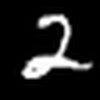

Prediction: 2


In [25]:
from IPython.display import display
from modules import load, predict
from PIL import Image

w, b, classes, input_labels, layers = load("models/model.bin")

img_path = "data/test/2/208.png"
number = Image.open(img_path).resize((100, 100), Image.Resampling.LANCZOS)
print("Input image:")
display(number)

pred = predict(img_path, w, b, len(layers)-1, classes)
print("Prediction:", pred)

# Behind the scene

<img src="assets/animation.gif">